# Trabajo Práctico - Aprendizaje Automático

## Imports y Seed


In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate

In [2]:
SEED = 2026

np.random.seed(SEED)


## Separación de Datos de Desarrollo y Control?

In [3]:
df_completo = pd.read_csv('data.csv')

In [4]:
def train_test_split(df, p):
    buen_pronostico = df[df['target'] == 1]
    mal_pronostico = df[df['target'] == 0]
    buenos = len(buen_pronostico)/len(df)
    filasBuenas = int(len(df)*buenos*p)
    filasMalas = int(len(df)*p-filasBuenas)
    # buscar como selecciona .sample()
    test = pd.DataFrame(columns=buen_pronostico.columns).astype(buen_pronostico.dtypes)
    test = pd.concat([test, buen_pronostico.sample(n=filasBuenas, random_state=SEED)], ignore_index=False)
    test = pd.concat([test, mal_pronostico.sample(n=filasMalas, random_state=SEED)], ignore_index=False)

    train = df.drop(test.index, axis=0)    
    return test, train

In [5]:
# Definimos el dataset que usaremos para desarrollar el modelo y el dataset de control que usaremos para evaluar el modelo.
df, df_control = train_test_split(df_completo, 0.2)

df.describe()

,rTjs,Sgqo,egGJ,DwEY,Qnno,NebZ,rVTD,eRIp,BbAh,OYJu,...,YfJW,LXKN,GcAh,qTSh,TgIh,kpDd,QDQf,TPVx,FbdX,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.230338,3.714620,-0.554732,0.060436,-0.141606,-0.057653,0.151762,0.038840,-0.086727,0.342660,...,0.072810,0.024372,0.119517,0.072152,-0.521372,0.066774,0.180978,0.093117,0.017123,0.280000
std,14.379983,13.995021,3.924077,0.945474,1.091915,0.927576,1.023263,0.883684,0.956951,3.791645,...,1.039881,0.960315,0.956441,0.987443,3.876253,0.904784,0.998685,0.977133,1.008473,0.451261
min,-33.717798,-43.488182,-8.113299,-2.455270,-2.347146,-2.237323,-2.290523,-1.825294,-2.425049,-12.367832,...,-2.557129,-1.813335,-1.884156,-2.452867,-9.979511,-2.424045,-2.109419,-1.940683,-3.823443,0.000000
25%,-9.830767,-4.399376,-2.979104,-0.586367,-0.977913,-0.712038,-0.319197,-0.539233,-0.788110,-2.031782,...,-0.595750,-0.635290,-0.475336,-0.669831,-3.006619,-0.522806,-0.445798,-0.537612,-0.722238,0.000000
50%,0.871102,3.744748,-0.396046,0.063287,-0.045784,-0.064252,0.161887,0.045337,-0.052450,0.657091,...,-0.018257,-0.033565,0.169313,-0.002808,-0.684173,-0.043821,0.136595,0.067955,0.013224,0.000000
75%,10.498683,13.762758,2.085142,0.777253,0.707147,0.581426,0.936482,0.579902,0.661366,2.840042,...,0.670726,0.704069,0.695173,0.750108,2.073117,0.730427,0.900123,0.719877,0.772552,1.000000
max,48.932149,38.257637,8.396918,2.450537,2.090458,2.275377,2.135502,2.718077,2.491669,8.157696,...,2.743871,3.034521,2.796046,2.372385,9.754154,1.967523,3.136959,2.770596,2.091279,1.000000


In [12]:
buen_pronostico = dataframe[dataframe['target'] == 1]
mal_pronostico = dataframe[dataframe['target'] == 0]
buenos = len(buen_pronostico)/500
# buscar como selecciona .sample()
control = pd.DataFrame(columns=buen_pronostico.columns)
control = pd.concat([control, buen_pronostico.sample(n=28)], ignore_index=False)
control = pd.concat([control, mal_pronostico.sample(n=72)], ignore_index=False)

# elegimos mantener las proporciones para no modificar la 
# distribución de los datos inicial, no elegimos random por que puede
# ocurrir que una clase quede subrepresentada y no se evalué correctamente
# el modelo sobre esa clase. 
# No hicimos nada más complejo para evitar data leakage.
control.index

Index([ 32, 324, 385,   3, 238,  24, 270, 497, 233, 460, 335,  92, 294, 493,
        56, 386, 288, 491, 182, 387,  20, 295, 104, 312, 433, 428, 158, 341,
       257, 394, 333, 459, 140,  86, 492, 383, 127, 461, 338,  60,  28, 401,
       283, 121, 216, 200, 120, 154,  58, 108, 130, 156,  64, 192, 245, 291,
       115, 226, 468,  81, 407, 376, 454, 352, 166, 133, 293, 325, 342, 345,
        83, 473, 337, 489, 110, 155, 275,  42, 188, 399, 449, 452, 189, 131,
       149, 350,  96,  98, 440, 118, 279, 266, 175, 231, 415, 438, 273, 251,
       439, 162],
      dtype='int64')

## Ejer 2

### Ejer 2.1

### Ejer 2.2

## Ejer 3

## Ejer 4

## Viendo cosas de varianza

In [26]:
std_total = df.drop(columns=['target']).std()
media_total = df.drop(columns=['target']).mean()
cv_total = (std_total / media_total).abs()

var_total = df.drop(columns=['target']).var()
var_por_clase = df.groupby('target').var().T

df_stats = pd.DataFrame({
    'Varianza_Total': var_total,
    'CV_Total': cv_total,
    'Varianza_Clase_0': var_por_clase[0], # Ni idea si sirve de algo para la clase, pero ya que estoy
    'Varianza_Clase_1': var_por_clase[1]
})

df_stats.sort_values(by='CV_Total', ascending=True)

,Varianza_Total,CV_Total,Varianza_Clase_0,Varianza_Clase_1
vrzO,12.695215,1.986771,10.489666,16.879349
kqbE,15.075618,2.420543,15.469923,14.172403
qSdK,10.753284,2.467021,11.012330,8.786185
DxHE,13.814117,2.485262,14.612840,12.057482
yzhI,249.852399,2.586783,275.248782,190.325555
...,...,...,...,...
lCvP,18.239223,616.810600,18.431418,15.932224
cDXl,0.746252,1011.984079,0.756103,0.740567
cxfm,1.017603,2866.144346,1.094777,0.803973
IFFd,0.671414,3083.463641,0.653007,0.692417


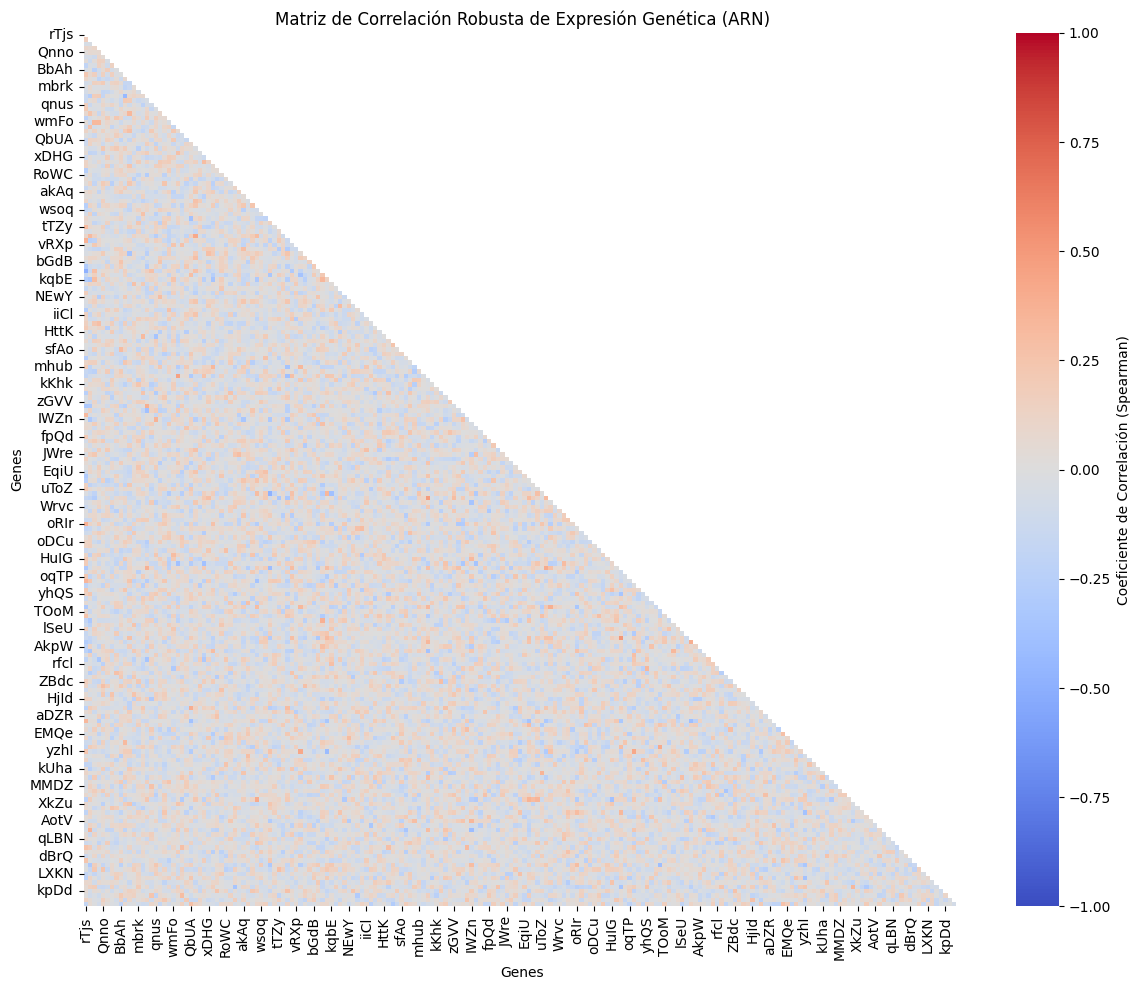

UKOa  GLoy    0.511371
dtype: float64


In [24]:
X = df.drop(columns=['target'])

matriz_corr = X.corr(method='spearman')

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_corr, 
    mask=mask, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1, 
    cbar_kws={'label': 'Coeficiente de Correlación (Spearman)'}
)
plt.title('Matriz de Correlación Robusta de Expresión Genética (ARN)')
plt.xlabel('Genes')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

correlaciones_apiladas = matriz_corr.mask(mask).stack()
correlaciones_fuertes = correlaciones_apiladas[abs(correlaciones_apiladas) > 0.5].sort_values(ascending=False)
print(correlaciones_fuertes)